In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('Success')

Success


In [ ]:
TICKER = 'AAPL'  

stock = yf.Ticker(TICKER)
df = stock.history(period='2y')
df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
df.dropna(inplace=True)

print(f'Ticker : {TICKER}')
print(f'Rows   : {len(df)}')
print(f'From   : {df.index[0].date()}')
print(f'To     : {df.index[-1].date()}')

In [ ]:
df.head()

,Open,High,Low,Close,Volume
Date,,,,,
2024-06-26 00:00:00-04:00,209.683623,213.014768,208.831009,211.418594,66213200
2024-06-27 00:00:00-04:00,212.846221,213.887206,210.526321,212.261292,49772700
2024-06-28 00:00:00-04:00,213.916937,214.214364,208.493913,208.811157,82542700
2024-07-01 00:00:00-04:00,210.268566,215.642017,210.100028,214.888550,60402900
2024-07-02 00:00:00-04:00,214.293669,218.487352,213.252698,218.378296,58046200


In [ ]:
df.tail()

,Open,High,Low,Close,Volume
Date,,,,,
2026-06-22 00:00:00-04:00,297.309998,302.420013,296.760010,297.010010,44879900
2026-06-23 00:00:00-04:00,297.540009,301.640015,294.179993,294.299988,52010900
2026-06-24 00:00:00-04:00,295.359985,299.700012,292.940002,293.079987,53081900
2026-06-25 00:00:00-04:00,287.399994,288.799988,273.750000,275.149994,107013700
2026-06-26 00:00:00-04:00,275.000000,280.470001,274.209991,278.959991,26487112


In [ ]:
print('Shape:', df.shape)
print()
df.info()

Shape: (502, 5)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-06-26 00:00:00-04:00 to 2026-06-26 00:00:00-04:00
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    502 non-null    float64
 1   High    502 non-null    float64
 2   Low     502 non-null    float64
 3   Close   502 non-null    float64
 4   Volume  502 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 23.5 KB


In [ ]:
# Basic statistics — min, max, mean etc
df.describe().round(2)

,Open,High,Low,Close,Volume
count,502.00,502.00,502.00,502.00,5.020000e+02
mean,240.12,242.75,237.71,240.31,5.159907e+07
std,28.56,28.62,28.46,28.42,2.356701e+07
min,171.05,189.34,168.32,171.51,1.791060e+07
25%,219.64,222.41,217.51,220.05,3.943802e+07
50%,233.37,236.01,231.68,234.30,4.617440e+07
75%,259.69,262.21,257.69,260.51,5.518310e+07
max,314.18,317.40,309.65,315.20,3.186799e+08


In [ ]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)


Missing values per column:
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

No missing values found!


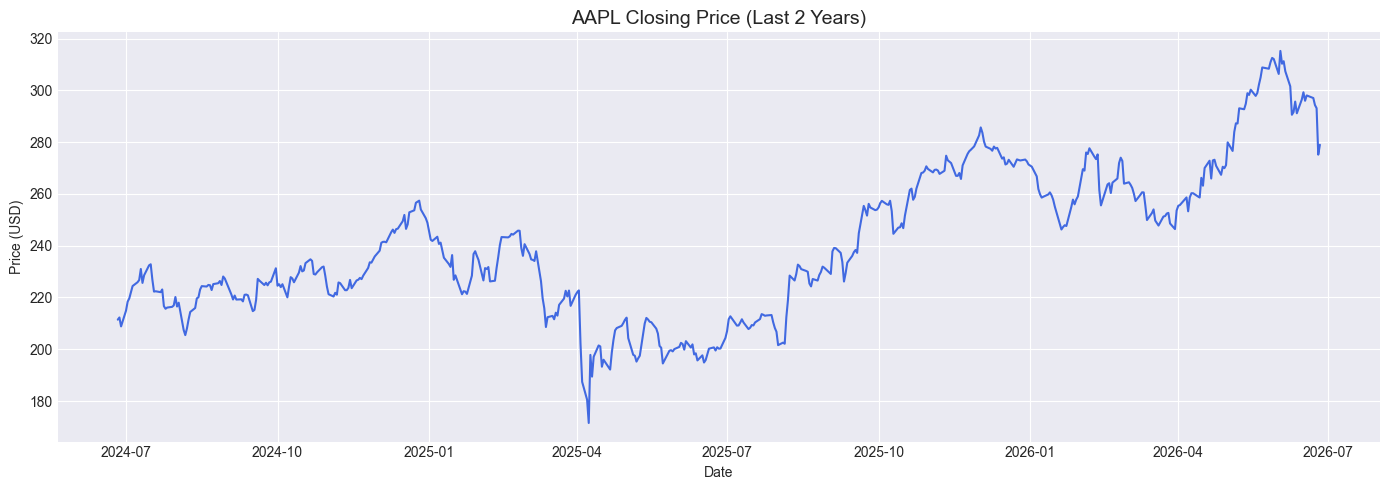

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color='royalblue', linewidth=1.5)
plt.title(f'{TICKER} Closing Price (Last 2 Years)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()

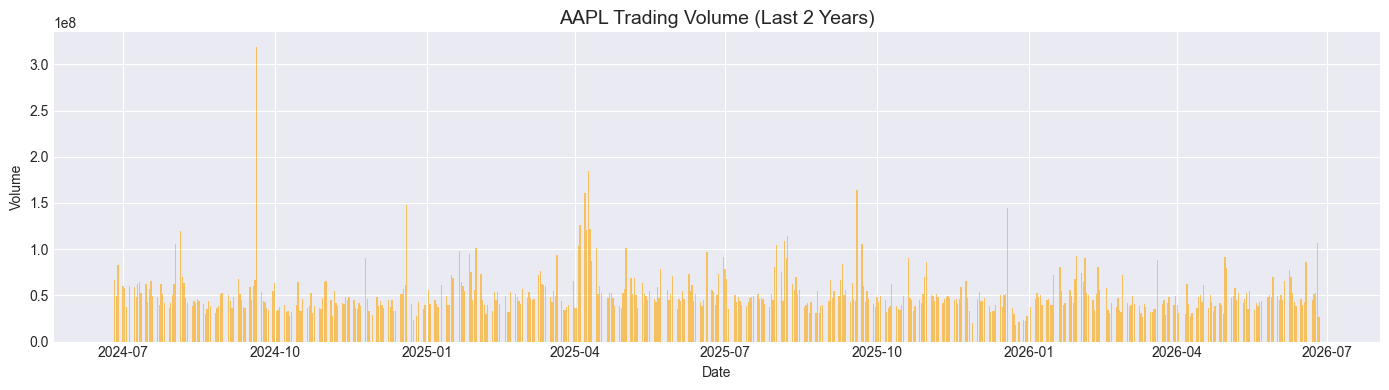

In [ ]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.6)
plt.title(f'{TICKER} Trading Volume (Last 2 Years)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Volume')
plt.tight_layout()
plt.show()

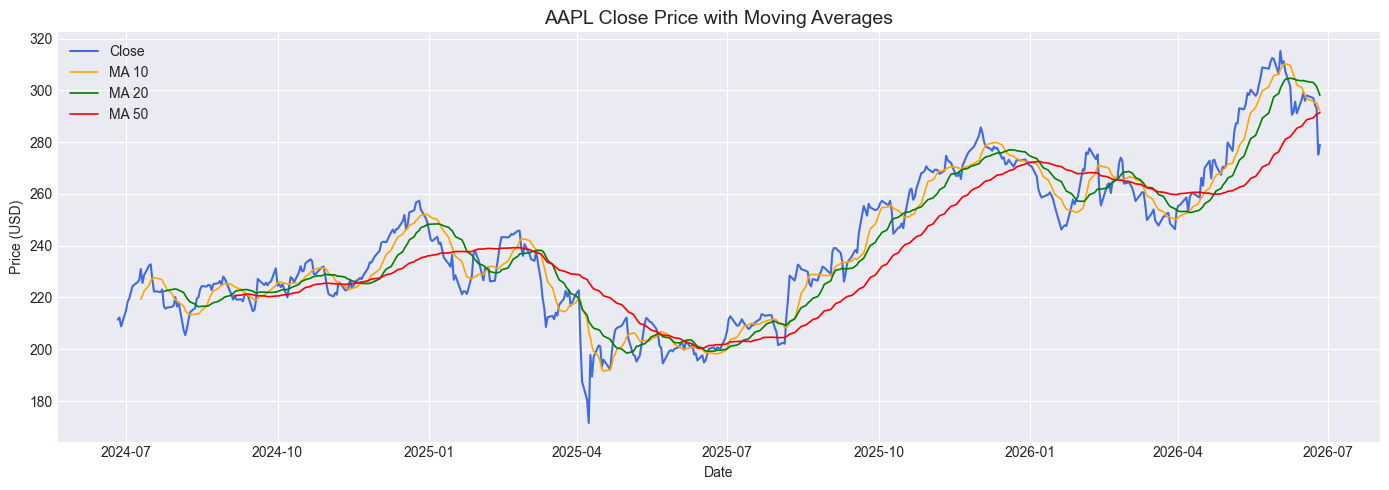

In [ ]:
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Close'],  label='Close',  linewidth=1.5, color='royalblue')
plt.plot(df['MA_10'],  label='MA 10',  linewidth=1.2, color='orange')
plt.plot(df['MA_20'],  label='MA 20',  linewidth=1.2, color='green')
plt.plot(df['MA_50'],  label='MA 50',  linewidth=1.2, color='red')
plt.title(f'{TICKER} Close Price with Moving Averages', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

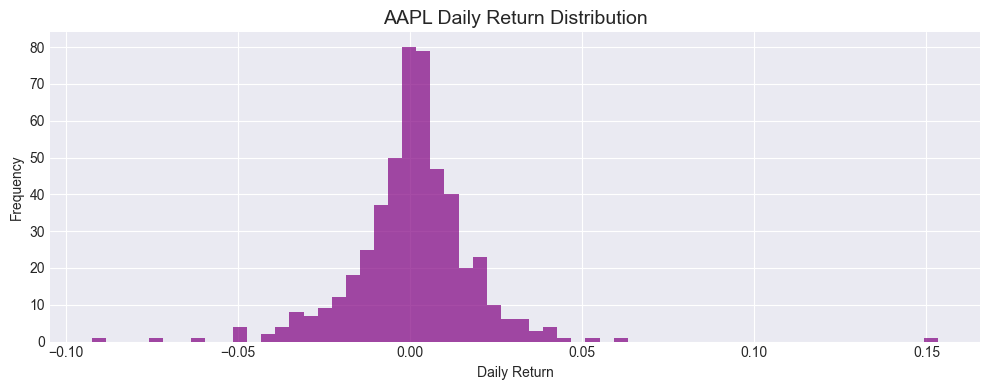

Average daily return : 0.0007
Std deviation        : 0.0177
Max single day gain  : 0.1533
Max single day loss  : -0.0925


In [ ]:
df['Return_1d'] = df['Close'].pct_change(1)

plt.figure(figsize=(10, 4))
df['Return_1d'].hist(bins=60, color='purple', alpha=0.7)
plt.title(f'{TICKER} Daily Return Distribution', fontsize=14)
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(f'Average daily return : {df["Return_1d"].mean():.4f}')
print(f'Std deviation        : {df["Return_1d"].std():.4f}')
print(f'Max single day gain  : {df["Return_1d"].max():.4f}')
print(f'Max single day loss  : {df["Return_1d"].min():.4f}')

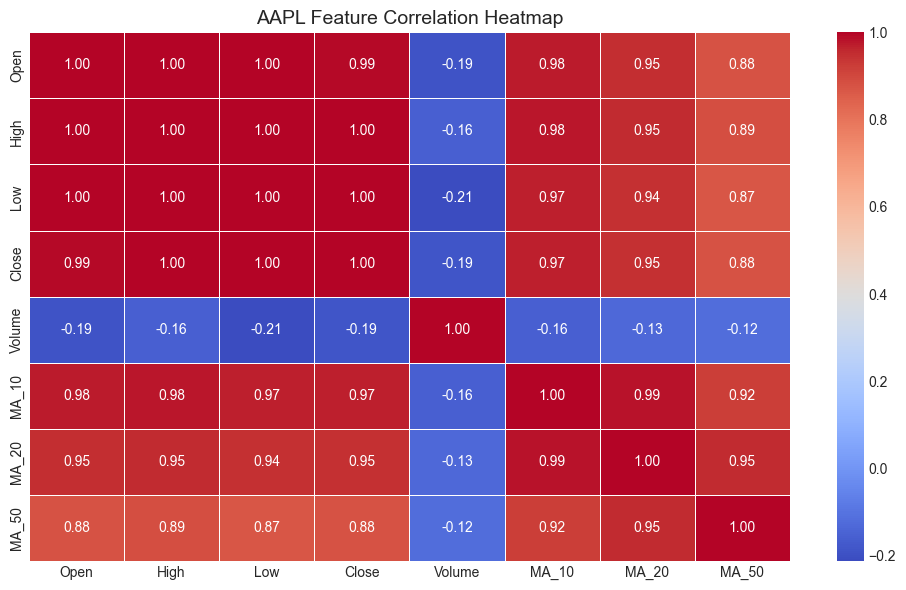

In [ ]:
corr = df[['Open', 'High', 'Low', 'Close', 'Volume', 'MA_10', 'MA_20', 'MA_50']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title(f'{TICKER} Feature Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()